In [1]:
#pip install pandas networkx matplotlib

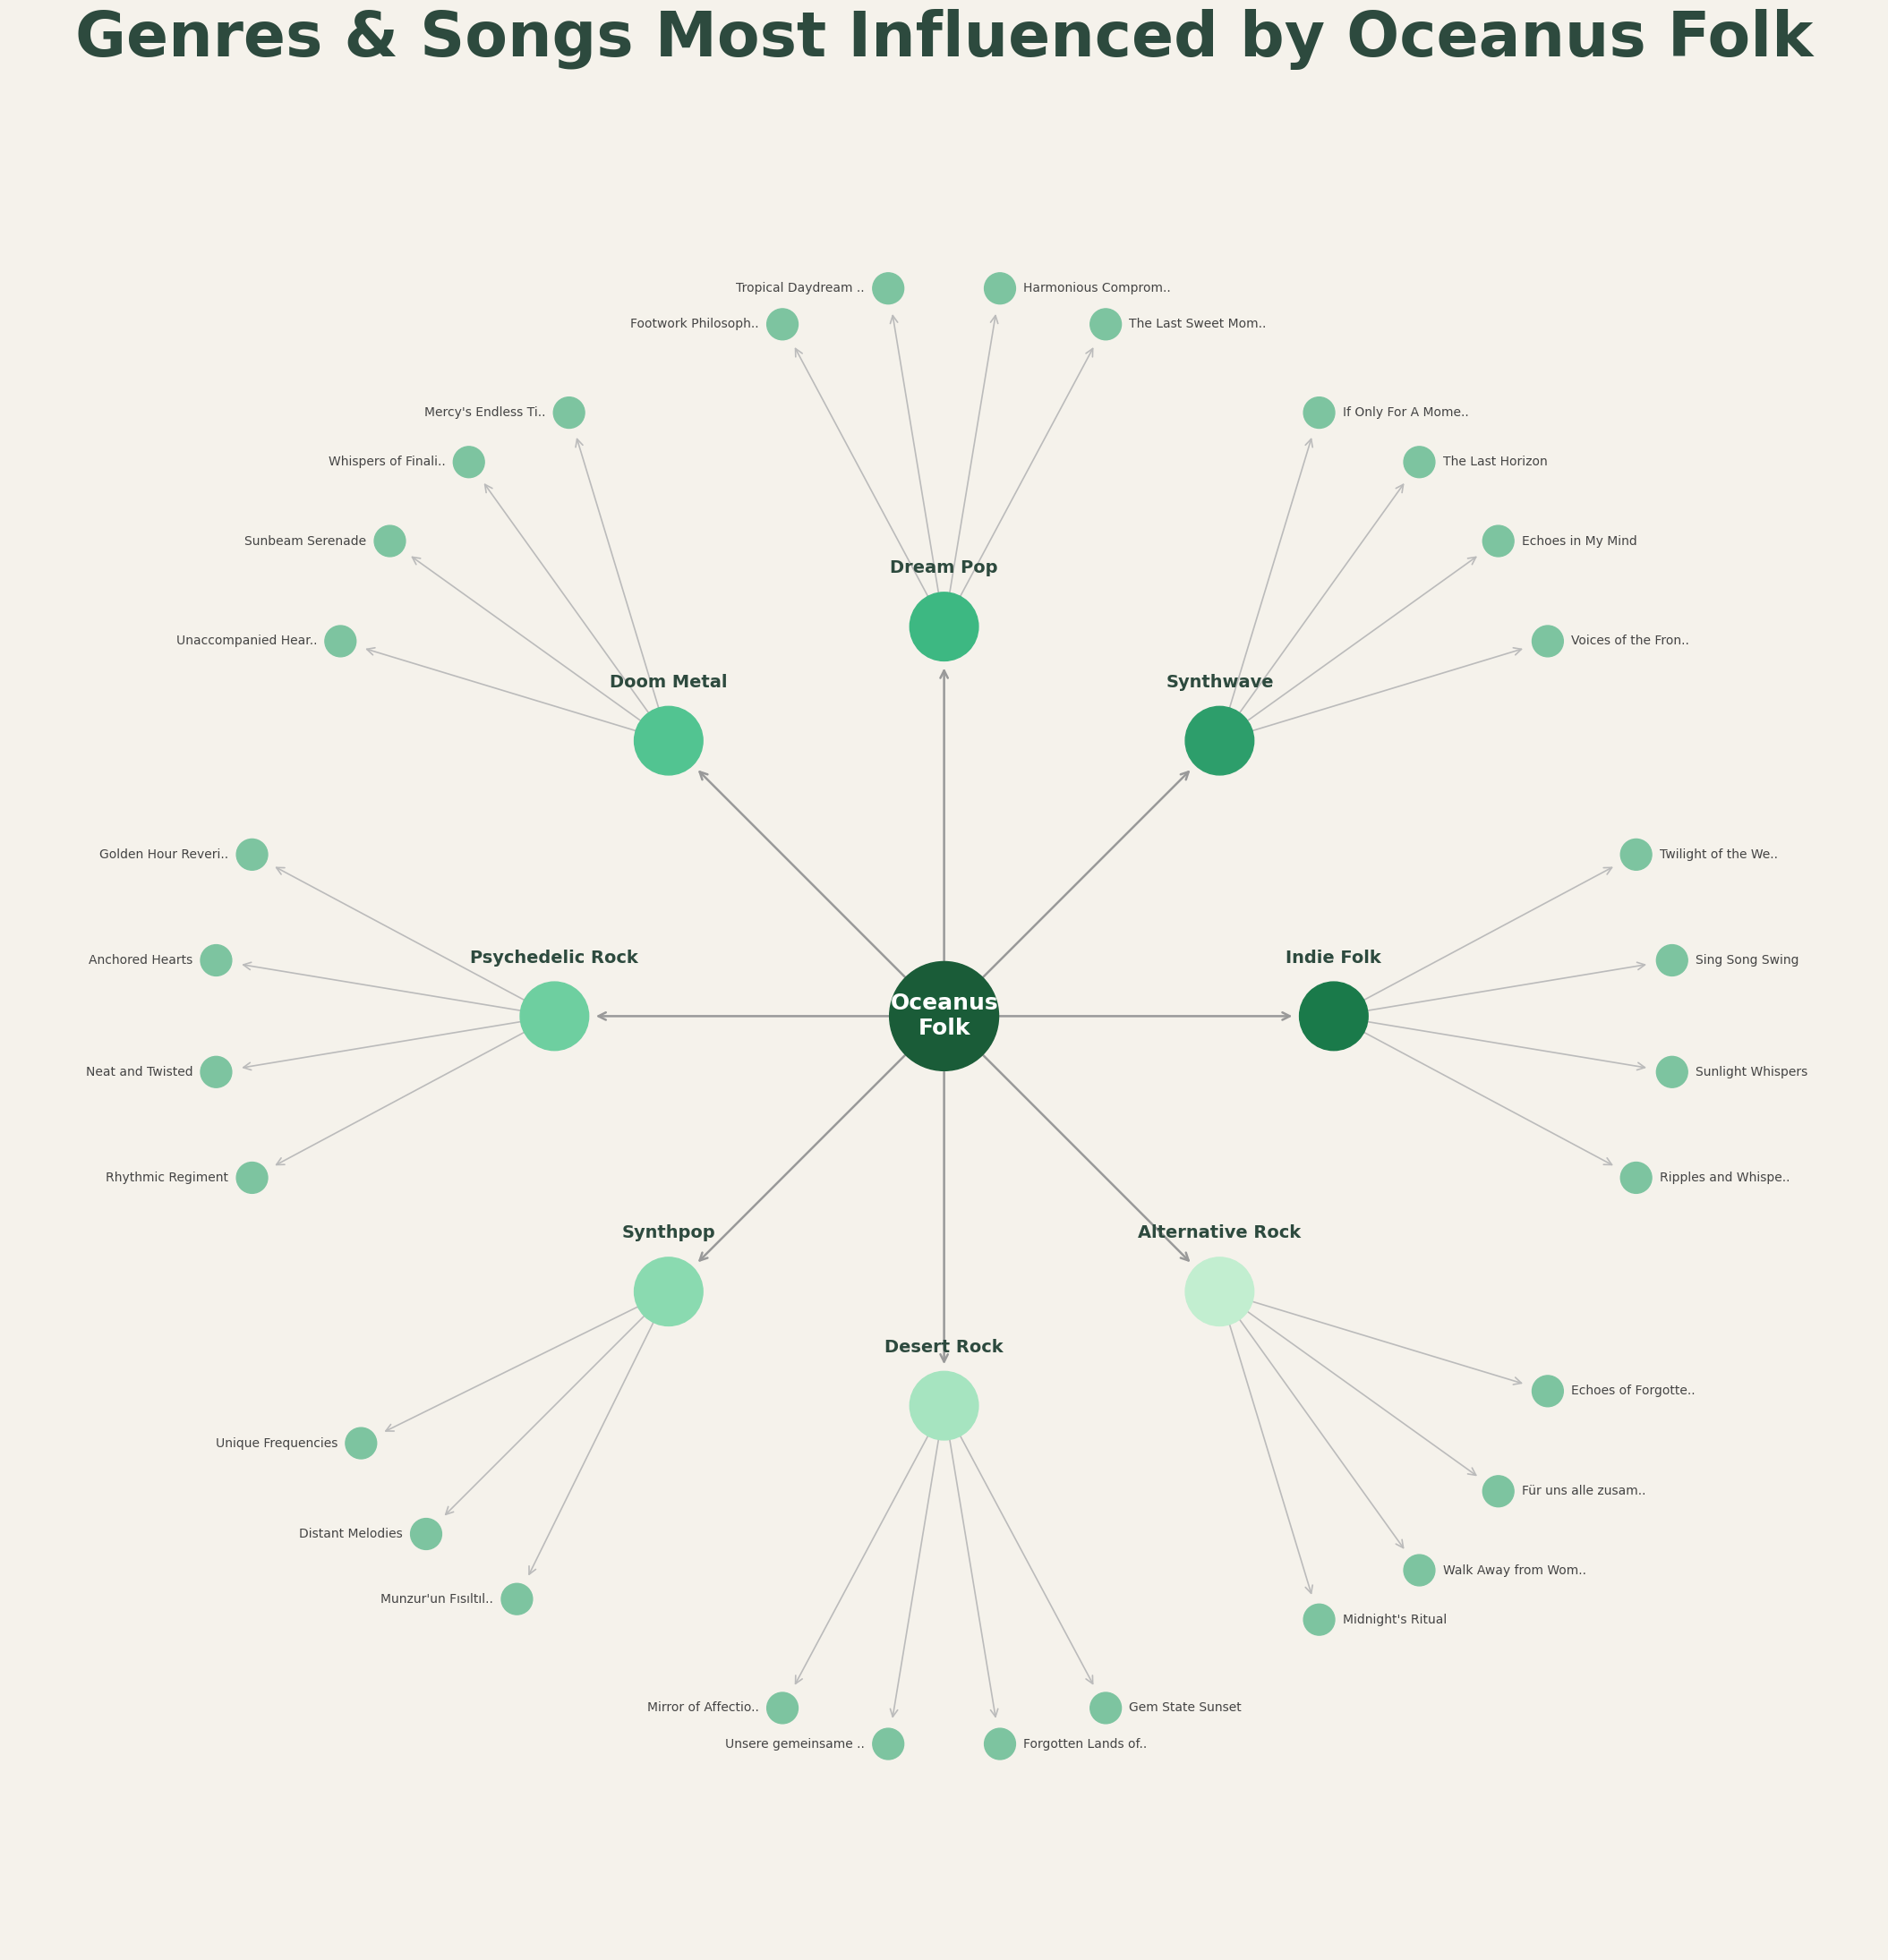

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('edges_prepped.csv')

influence_types = ['InterpolatesFrom', 'InStyleOf', 'CoverOf', 'LyricalReferenceTo']

infl = df[
    (df['Edge Type'].isin(influence_types)) &
    (df['source_genre'] == 'Oceanus Folk') &
    (df['target_genre'].notna()) &
    (df['target_genre'] != 'Oceanus Folk')
].copy()

genre_counts = infl['target_genre'].value_counts().head(8)

# Build tree structure
G = nx.DiGraph()
center = 'Oceanus Folk'
G.add_node(center, level=0)

for genre, count in genre_counts.items():
    G.add_node(genre, level=1)
    G.add_edge(center, genre)
    artists = infl[infl['target_genre'] == genre]['target_name'].value_counts().head(4).index.tolist()
    for artist in artists:
        short = artist[:18] + '..' if len(artist) > 18 else artist
        node_id = f"{genre}||{short}"
        G.add_node(node_id, level=2, label=short)
        G.add_edge(genre, node_id)

# Manual radial layout
def radial_layout(G, center):
    pos = {}
    pos[center] = (0, 0)
    
    genres = list(G.successors(center))
    n_genres = len(genres)
    
    for i, genre in enumerate(genres):
        angle = 2 * np.pi * i / n_genres
        gx = 2.5 * np.cos(angle)
        gy = 2.5 * np.sin(angle)
        pos[genre] = (gx, gy)
        
        leaves = list(G.successors(genre))
        n_leaves = len(leaves)
        spread = np.pi / (n_genres * 1.2)
        
        for j, leaf in enumerate(leaves):
            if n_leaves > 1:
                leaf_angle = angle + spread * (j - (n_leaves - 1) / 2)
            else:
                leaf_angle = angle
            lx = gx + 2.2 * np.cos(leaf_angle)
            ly = gy + 2.2 * np.sin(leaf_angle)
            pos[leaf] = (lx, ly)
    
    return pos

pos = radial_layout(G, center)

fig, ax = plt.subplots(figsize=(22, 22), facecolor='#f5f2eb')
ax.set_facecolor('#f5f2eb')
ax.axis('off')


# Draw edges with arrows
for u, v in G.edges():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    level_u = G.nodes[u].get('level', 0)
    color = '#999' if level_u == 0 else '#bbb'
    lw = 1.8 if level_u == 0 else 1.2

    # Shorten the arrow so it stops before the target circle
    dx = x2 - x1
    dy = y2 - y1
    dist = np.sqrt(dx**2 + dy**2)

    # Shrink amount based on level (match circle sizes)
    shrink = 0.25 if level_u == 0 else 0.15

    # New endpoint slightly before the target node
    x2_new = x2 - (dx / dist) * shrink
    y2_new = y2 - (dy / dist) * shrink

    ax.annotate('',
        xy=(x2_new, y2_new),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='->',
            color=color,
            lw=lw,
            mutation_scale=15
        ),
        zorder=1
    )

# Draw nodes and labels
genre_colors = ['#1a7a4a','#2d9e6b','#3db882','#52c491',
                '#6ecfa0','#8adab0','#a6e4c0','#c2eed0']

for node in G.nodes():
    x, y = pos[node]
    level = G.nodes[node].get('level', 0)
    
    if level == 0:
        circle = plt.Circle((x, y), 0.35, color='#1a5c38', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, 'Oceanus\nFolk', ha='center', va='center',
                fontsize=18, fontweight='bold', color='white', zorder=4)
    
    elif level == 1:
        gi = list(G.successors(center)).index(node)
        color = genre_colors[gi % len(genre_colors)]
        circle = plt.Circle((x, y), 0.22, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y + 0.32, node, ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='#2d4a3e', zorder=4)
    
    else:
        circle = plt.Circle((x, y), 0.1, color='#7dc4a0', zorder=3)
        ax.add_patch(circle)
        label = G.nodes[node].get('label', node.split('||')[1])
        angle = np.degrees(np.arctan2(y, x))
        if -90 <= angle <= 90:
            ha = 'left'
            offset_x = 0.15
        else:
            ha = 'right'
            offset_x = -0.15
        ax.text(x + offset_x, y, label, ha=ha, va='center',
                fontsize=10, color='#444', zorder=4)

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')

plt.title('Genres & Songs Most Influenced by Oceanus Folk',
          fontsize=50, fontweight='bold', color='#2d4a3e', pad=20)

plt.tight_layout()
plt.savefig('oceanus_folk_radial_tree.png', 
            dpi=300, bbox_inches='tight', facecolor='#f5f2eb')
plt.show()

What each level tells you
Center — Oceanus Folk
This is the origin point. All influence radiates outward from here.
Middle ring — the genres
These are the genres whose songs drew inspiration from Oceanus Folk. The key takeaway:

Indie Folk is by far the most influenced — it has the most songs branching out from it
Synthwave, Dream Pop, Doom Metal are the next most influenced
Genres like Desert Rock and Alternative Rock show smaller but still notable influence

Outer ring — the songs
These are actual songs within each genre that directly referenced, covered, interpolated, or styled themselves after Oceanus Folk songs. They show that the influence is concrete and traceable, not just a general trend.

The story for Silas Reed's article
Oceanus Folk didn't just stay on the island — it reached deep into the global music scene, most powerfully into Indie Folk which shares its acoustic, storytelling roots. The influence then rippled outward into more unexpected genres like Synthwave and Doom Metal, showing just how far Oceanus Folk has traveled musically. 